In [ ]:
"""
Задание 1. Задача классификации
Для набора данных "Ирисы Фишера":

1)Загрузить данные, разбить на тренировочную и обучающую выборки.
2)Обучить на тренировочной, оценить точность модели на тестовой выборке для GaussianNB(), MultinomialNB(), KNeighborsClassifier().
  Прокомментировать полученные результаты. 
  В каждом случае построить матрицы ConfusionMatrix, отчеты о классификации (4 балла).
3)Показать, что точность модели kNN зависит от выбранного числа соседей (2 балла).
При желании можно строить и границы решений. Для этого будет полезна следующая функция. 
Но, обратите внимание, в ней используются только 2 признака (из 4 в рассматриваемом наборе).
"""

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [7]:
"""
Загружаем данные "Ирисы Фишера"
Где X - 4 признака ( длина/ширина чашелистика и лепестка);
    y - метки классов (0,1,2 - три вида ирисов)
X_train, X_test, y_train, y_test - разделение на обучающую и тестовую
"""

X, y = load_iris(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5)


Модель: GaussianNB
Accuracy: 0.9210526315789473
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.87      0.93      0.90        14
           2       0.91      0.83      0.87        12

    accuracy                           0.92        38
   macro avg       0.93      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



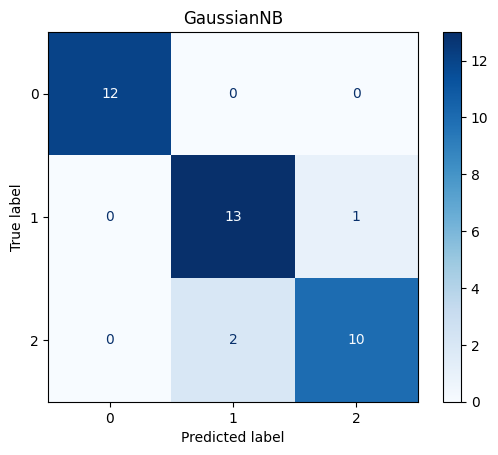


Модель: MultinomialNB
Accuracy: 0.868421052631579
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.64      0.78        14
           2       0.71      1.00      0.83        12

    accuracy                           0.87        38
   macro avg       0.90      0.88      0.87        38
weighted avg       0.91      0.87      0.87        38



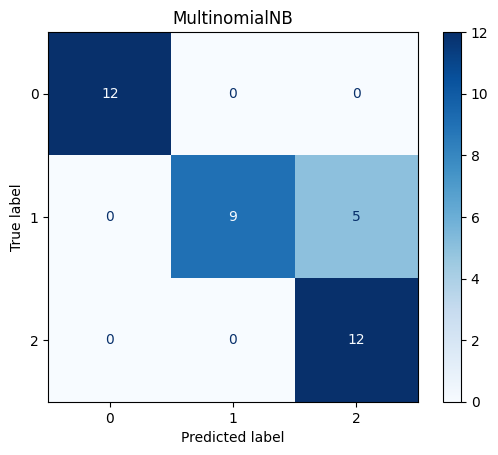


Модель: KNN (k=3)
Accuracy: 0.9473684210526315
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.86      0.92        14
           2       0.86      1.00      0.92        12

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



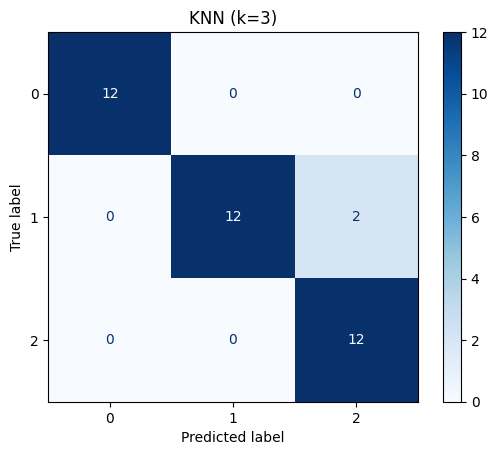

In [10]:
# Словарь моделей
models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3)
}

# Запуск моделей
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\nМодель: {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap="Blues")
    plt.title(name)
    plt.show()

In [ ]:
"""
Результаты:
1
Модель: GaussianNB
Видим, что Accuracy (правильность): 0.9210526315789473, так как модель GaussianNB немного ошиблась в классификации цветков по признакам.

Рассмотрим таблицу:
Для класса 0 - Setosa - Определяется без ошибок (precision = 1.00, recall = 1.00, f1 = 1.00)
Для класса 1 - (Versicolor) и класса 2 - (Virginica) - определяются с ошибками:
    *несколько объектов класса 2 перепутаны с классом 1;
    *один объект класса 1 перепутан с классом 2.
Precision и Recall для классов 1 и 2 находятся в пределах 83–93%, F1 ≈ 0.87–0.90.
Ошибки носят симметричный характер: оба класса иногда путаются друг с другом, но не с классом 0.

Модель очень надёжна для распознавания класса 0, но в области перекрытия классов 1 и 2 она не всегда уверенно различает цветы.

GaussianNB на Iris показывает высокую точность (92%), идеально классифицирует setosa, 
но путает часть объектов между versicolor и virginica, что соответствует известной сложности этого датасета.
"""

"""
Результаты:
2
Модель: MultinomialNB
Видим, что Accuracy (правильность): 0.868421052631579, т.е. ошибается чаще чем предыдущая модель, но не смотря на это, 
класс 0 также правильно ответила.

Рассмотрим таблицу:
Для класса 0 - Setosa - Определяется без ошибок (precision = 1.00, recall = 1.00, f1 = 1.00).
Класс 1 (Versicolor): из 14 объектов → 9 верно, 5 перепутаны с классом 2.
    precision = 1.00 (модель никогда не ошибалась, предсказывая "1"),
    recall = 0.64 (нашла только 9 из 14 объектов класса 1).
    → То есть модель «боится» предсказывать класс 1, и часть его объектов относит к классу 2.
Класс 2 (Virginica): 12 из 12 верно (100%).
    precision = 0.71 (из всех предсказаний "2" только 71% верные, потому что часть истинных 1 ушли в 2),
    recall = 1.00 (все объекты класса 2 найдены).
    → То есть модель «подтягивает» лишние объекты в класс 2, но зато не пропускает истинные 2.

MultinomialNB рассчитан на дискретные счётные признаки (например, количество слов в тексте).
Данные Iris — неподходящие для него (они вещественные, измеренные в сантиметрах).
Поэтому MultinomialNB искусственно «считает» признаки и работает хуже, чем GaussianNB, где предполагается нормальное распределение 
Лучше использовать GaussianNB или KNN для Iris, т.к. они дают более высокое качество.   
"""

"""
Результаты:
3
Модель: KNN (k=3)
Видим, что Accuracy (правильность): 0.9473684210526315, т.е. модель намного лучше работает, чем две предыдущие.

Рассмотрим таблицу:
Класс 0 (Setosa):
    precision = 1.00, recall = 1.00, f1 = 1.00 → идеально.

Класс 1 (Versicolor):
    precision = 1.00 (все предсказания «1» верны),
    recall = 0.86 (нашла 12 из 14),
    f1 ≈ 0.92.
    → Ошибки идут только в сторону класса 2.

Класс 2 (Virginica):
    precision = 0.86 (из 14 предсказанных «2» → 12 верные, 2 ошибочные с классом 1),
    recall = 1.00 (все истинные «2» найдены),
    f1 ≈ 0.92.
    → Модель никогда не пропускает virginica, но иногда «добавляет лишних» (перепутанных versicolor)

KNN не делает предположений о распределении признаков (в отличие от GaussianNB и MultinomialNB).
Вместо этого он ориентируется на «ближайших соседей» в исходном пространстве.
Для Iris, где классы 1 и 2 сильно пересекаются, KNN оказывается более гибким.
При k=3 он балансирует между шумоустойчивостью и точностью.
"""

'\nРезультаты:\n2\nМодель: MultinomialNB\nВидим, что Accuracy (правильность): 0.868421052631579, т.е. ошибается чаще чем предыдущая модель, но не смотря на это, \nкласс 0 также правильно ответила.\n\nРассмотрим таблицу:\nДля класса 0 - Setosa - Определяется без ошибок (precision = 1.00, recall = 1.00, f1 = 1.00).\nКласс 1 (Versicolor): из 14 объектов → 9 верно, 5 перепутаны с классом 2.\n    precision = 1.00 (модель никогда не ошибалась, предсказывая "1"),\n    recall = 0.64 (нашла только 9 из 14 объектов класса 1).\n    → То есть модель «боится» предсказывать класс 1, и часть его объектов относит к классу 2.\nКласс 2 (Virginica): 12 из 12 верно (100%).\n    precision = 0.71 (из всех предсказаний "2" только 71% верные, потому что часть истинных 1 ушли в 2),\n    recall = 1.00 (все объекты класса 2 найдены).\n    → То есть модель «подтягивает» лишние объекты в класс 2, но зато не пропускает истинные 2.\n\nMultinomialNB рассчитан на дискретные счётные признаки (например, количество слов 